# Milestone 1 — Exploratory Data Analysis
**Project:** Develop a Model to Predict Customer Churn in Telecommunication Sector  
**Team:** Benedicta Amoah, Delle Micheal, Arthur Lordys Nana Ama Kissiwaa, Essah Isaac  
**Supervisor:** Assoc. Prof. Peter Kwesi Nyarko — UMaT, Tarkwa, Ghana

---
This notebook covers:
1. Dataset overview and shape
2. Variable types and distributions
3. Missing value audit
4. Target variable (churn) distribution — class balance check
5. Univariate analysis — numerical & categorical features
6. Bivariate analysis — feature vs churn
7. Correlation analysis
8. Key observations and preprocessing decisions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

FIGURES = '../reports/figures'
import os; os.makedirs(FIGURES, exist_ok=True)

## 1. Load Datasets

In [2]:
telco = pd.read_excel('../data/raw/Telco_customer_churn.xlsx')
india = pd.read_csv('../data/raw/indian_telecom_customers.csv')

print(f'Telco XLSX  : {telco.shape[0]:,} rows × {telco.shape[1]} columns')
print(f'India CSV   : {india.shape[0]:,} rows × {india.shape[1]} columns')

Telco XLSX  : 7,043 rows × 33 columns
India CSV   : 15,000 rows × 39 columns


## 2. Dataset Overview

In [3]:
print('=== TELCO (IBM-inspired) — Column Summary ===')
telco.info()


=== TELCO (IBM-inspired) — Column Summary ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   st

In [4]:
print('=== INDIA — Column Summary ===')
india.info()


=== INDIA — Column Summary ===
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  str    
 1   name                        15000 non-null  str    
 2   phone                       15000 non-null  int64  
 3   gender                      15000 non-null  str    
 4   age                         15000 non-null  int64  
 5   city                        15000 non-null  str    
 6   state                       15000 non-null  str    
 7   pincode                     15000 non-null  int64  
 8   city_tier                   15000 non-null  str    
 9   profession                  15000 non-null  str    
 10  annual_income_lakhs         15000 non-null  float64
 11  is_married                  15000 non-null  bool   
 12  has_children                15000 non-null  bool   
 13  num_depende

In [5]:
print('=== TELCO — First 5 rows ===')
telco.head()

=== TELCO — First 5 rows ===


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [6]:
print('=== INDIA — First 5 rows ===')
india.head()

=== INDIA — First 5 rows ===


,customer_id,name,phone,gender,age,city,state,pincode,city_tier,profession,...,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score,is_festival_season,monsoon_impact,churn_probability,churn
0,IND000001,Arjun Bhatt,918332181960,Male,37,Indore,Maharashtra,198246,Tier 2,Student,...,0,1,3,2,1,4,False,False,0.683,Yes
1,IND000002,Kavya Bose,918940781618,Female,44,Kolkata,West Bengal,969693,Tier 1,Government Employee,...,0,4,2,5,2,3,False,False,0.498,Yes
2,IND000003,Ramesh Desai,917832764835,Male,25,Bhopal,Maharashtra,340174,Tier 2,Business Owner,...,1,6,4,9,5,8,False,False,0.657,Yes
3,IND000004,Geeta Tiwari,919532871012,Female,43,Faridabad,Maharashtra,930555,Tier 2,Government Employee,...,0,6,2,9,0,5,False,False,0.489,No
4,IND000005,Shubham Das,917252880957,Male,26,Mumbai,Maharashtra,217301,Tier 1,Private Employee,...,0,2,9,10,3,9,False,False,0.266,No


## 3. Missing Value Audit

In [7]:
def missing_report(df, name):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
    report = report[report['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
    if report.empty:
        print(f'{name}: No missing values.')
    else:
        print(f'{name} — Missing Values:')
        display(report)

missing_report(telco, 'TELCO')
missing_report(india, 'INDIA')

TELCO — Missing Values:


,Missing Count,Missing %
Churn Reason,5174,73.46


INDIA: No missing values.


In [8]:
# Total Charges in TELCO is object type — fix it
print('Telco Total Charges sample:', telco['Total Charges'].sample(10).tolist())
print('Unique non-numeric entries:', telco[pd.to_numeric(telco['Total Charges'], errors='coerce').isna()]['Total Charges'].unique())

Telco Total Charges sample: [3236.35, 1264.2, 3217.65, 1156.55, 1785.65, 2331.3, 6860.6, 70.6, 4528, 1016.7]
Unique non-numeric entries: [' ']


## 4. Target Variable Distribution

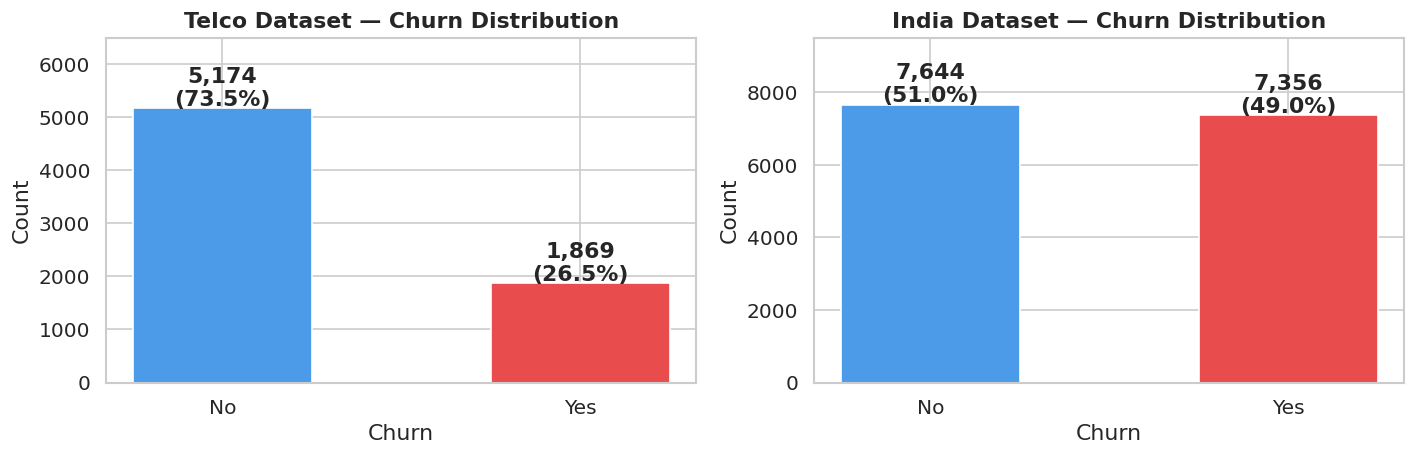

Telco churn rate: ~26.5% | India churn rate: ~49.0%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Telco
telco_counts = telco['Churn Label'].value_counts()
telco_pct = (telco_counts / len(telco) * 100).round(1)
axes[0].bar(telco_counts.index, telco_counts.values, color=['#4c9be8', '#e84c4c'], width=0.5)
for i, (v, p) in enumerate(zip(telco_counts.values, telco_pct.values)):
    axes[0].text(i, v + 50, f'{v:,}\n({p}%)', ha='center', fontweight='bold')
axes[0].set_title('Telco Dataset — Churn Distribution', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 6500)

# India
india_counts = india['churn'].value_counts()
india_pct = (india_counts / len(india) * 100).round(1)
axes[1].bar(india_counts.index, india_counts.values, color=['#4c9be8', '#e84c4c'], width=0.5)
for i, (v, p) in enumerate(zip(india_counts.values, india_pct.values)):
    axes[1].text(i, v + 80, f'{v:,}\n({p}%)', ha='center', fontweight='bold')
axes[1].set_title('India Dataset — Churn Distribution', fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, 9500)

plt.tight_layout()
plt.savefig(f'{FIGURES}/01_churn_distribution.png', bbox_inches='tight')
plt.show()
print('Telco churn rate: ~26.5% | India churn rate: ~49.0%')

## 5. Telco Dataset — Univariate Analysis

In [11]:
# Numerical features
telco['Total Charges'] = pd.to_numeric(telco['Total Charges'], errors='coerce')
telco_num = telco[['Tenure Months', 'Monthly Charges', 'Total Charges']].describe().round(2)
print('=== Telco Numerical Features — Descriptive Statistics ===')
display(telco_num)

=== Telco Numerical Features — Descriptive Statistics ===


,Tenure Months,Monthly Charges,Total Charges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


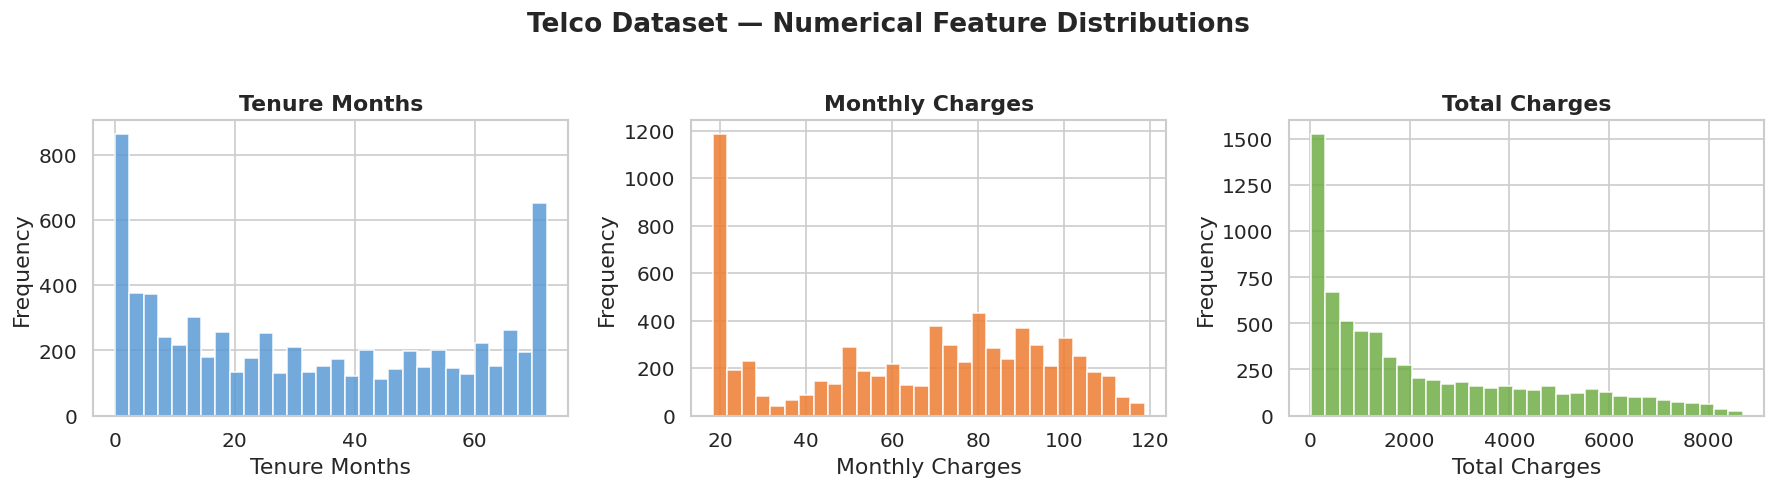

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']
colors = ['#5b9bd5', '#ed7d31', '#70ad47']

for ax, col, color in zip(axes, num_cols, colors):
    ax.hist(telco[col].dropna(), bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.suptitle('Telco Dataset — Numerical Feature Distributions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES}/02_telco_num_distributions.png', bbox_inches='tight')
plt.show()

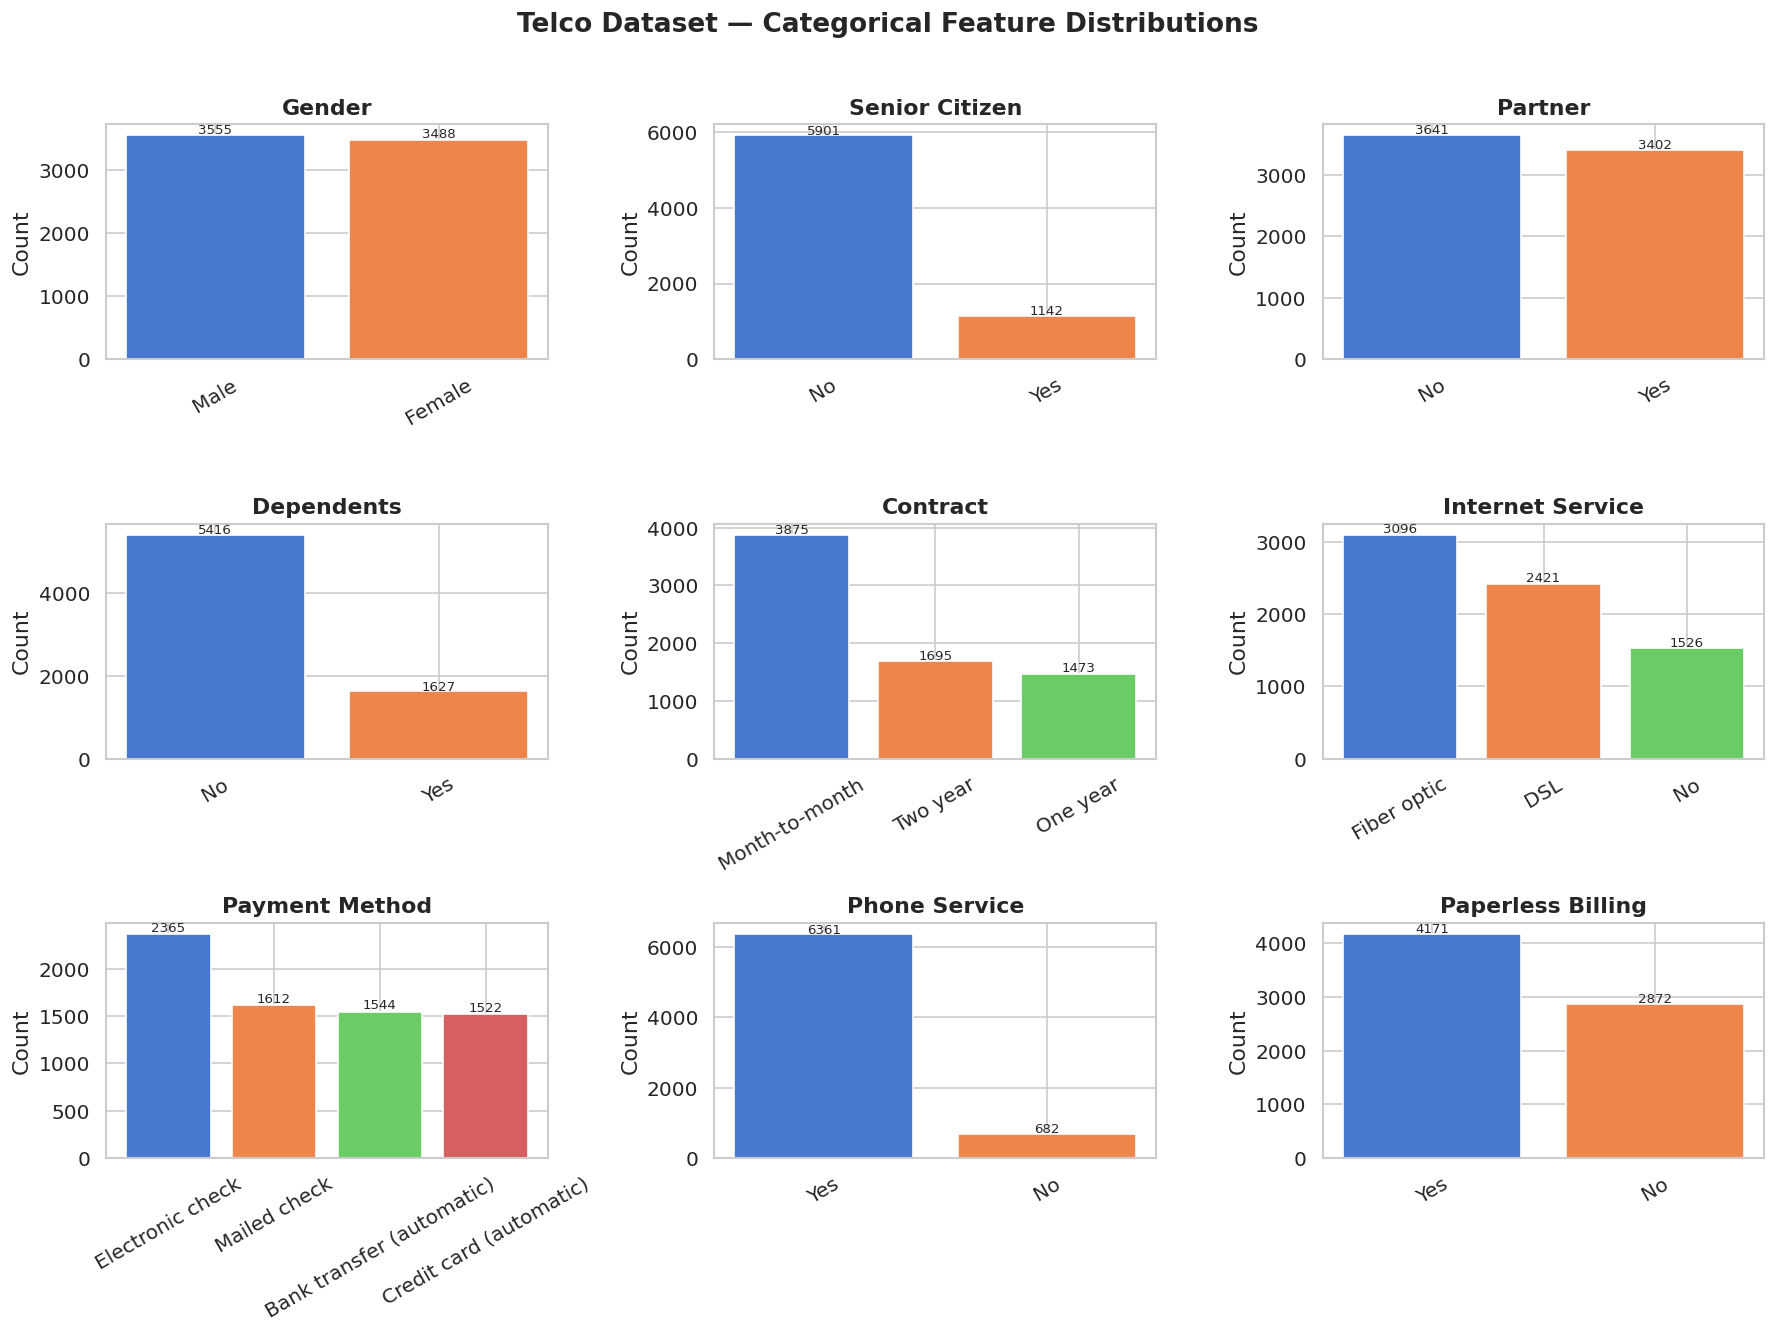

In [13]:
# Categorical features — top ones
telco_cat_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents',
                  'Contract', 'Internet Service', 'Payment Method',
                  'Phone Service', 'Paperless Billing']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, col in zip(axes, telco_cat_cols):
    vc = telco[col].value_counts()
    ax.bar(vc.index, vc.values, color=sns.color_palette('muted', len(vc)))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(vc.values):
        ax.text(i, v + 30, str(v), ha='center', fontsize=8)

plt.suptitle('Telco Dataset — Categorical Feature Distributions', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/03_telco_cat_distributions.png', bbox_inches='tight')
plt.show()

## 6. Telco Dataset — Bivariate Analysis (Feature vs Churn)

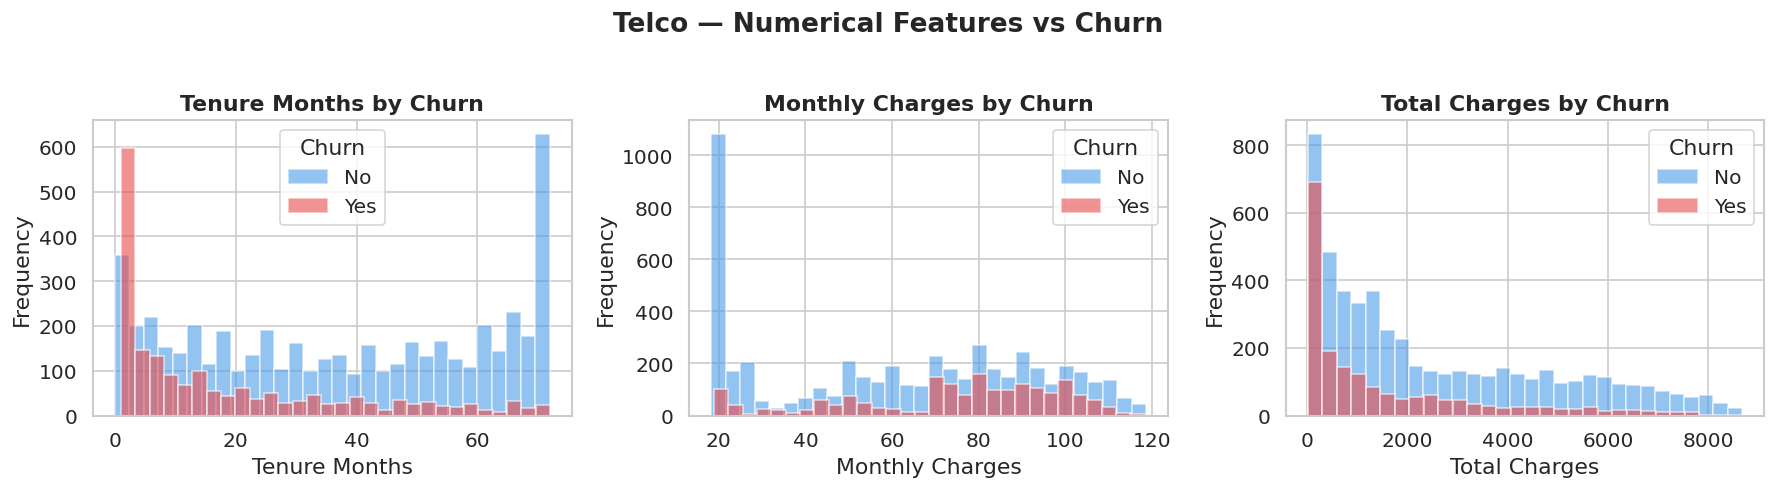

In [15]:
# Numerical features vs churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']
palette = {'No': '#4c9be8', 'Yes': '#e84c4c'}

for ax, col in zip(axes, num_cols):
    for label, grp in telco.groupby('Churn Label'):
        ax.hist(grp[col].dropna(), bins=30, alpha=0.6, label=label, color=palette[label], edgecolor='white')
    ax.set_title(f'{col} by Churn', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(title='Churn')

plt.suptitle('Telco — Numerical Features vs Churn', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES}/04_telco_num_vs_churn.png', bbox_inches='tight')
plt.show()

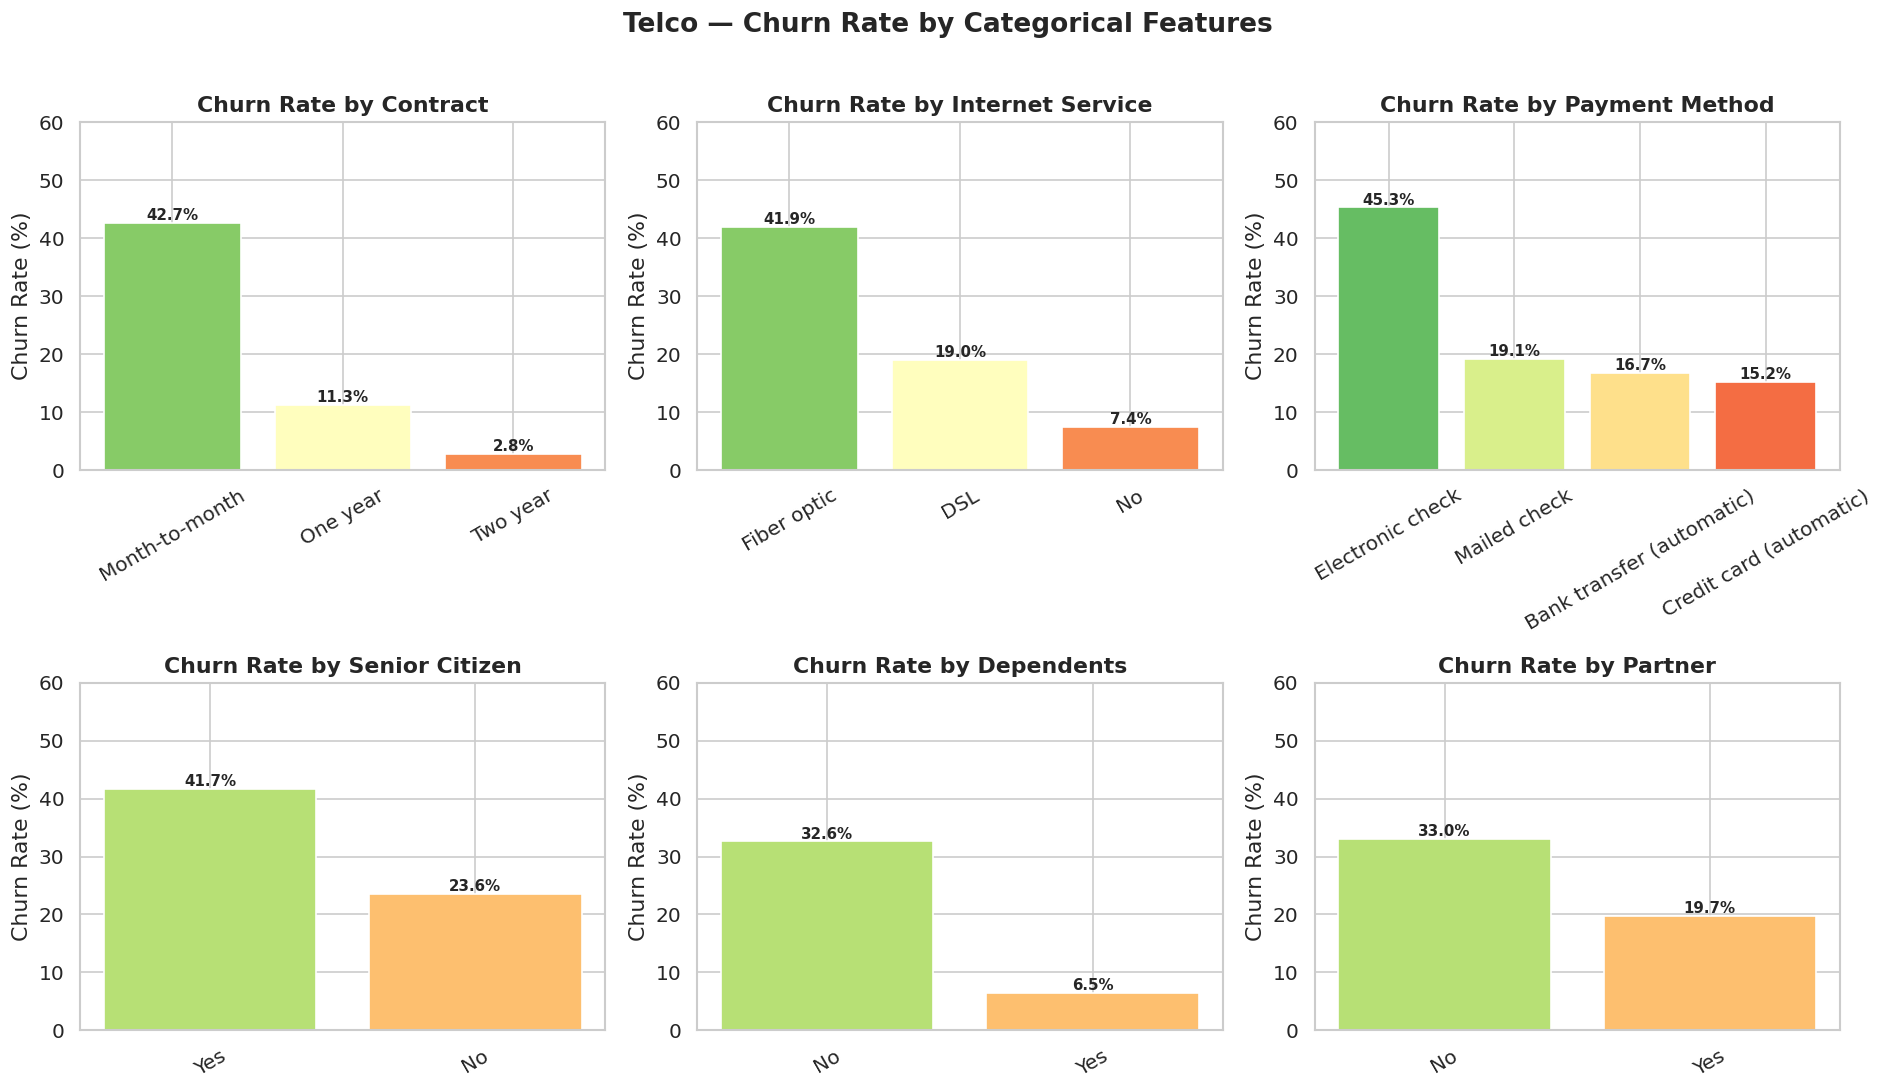

In [16]:
# Categorical features vs churn rate
cat_churn_cols = ['Contract', 'Internet Service', 'Payment Method',
                  'Senior Citizen', 'Dependents', 'Partner']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_churn_cols):
    churn_rate = (telco.groupby(col)['Churn Value']
                  .mean()
                  .sort_values(ascending=False) * 100).round(1)
    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color=sns.color_palette('RdYlGn_r', len(churn_rate)))
    ax.set_title(f'Churn Rate by {col}', fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(0, 60)
    for bar, v in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Telco — Churn Rate by Categorical Features', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/05_telco_cat_vs_churn.png', bbox_inches='tight')
plt.show()

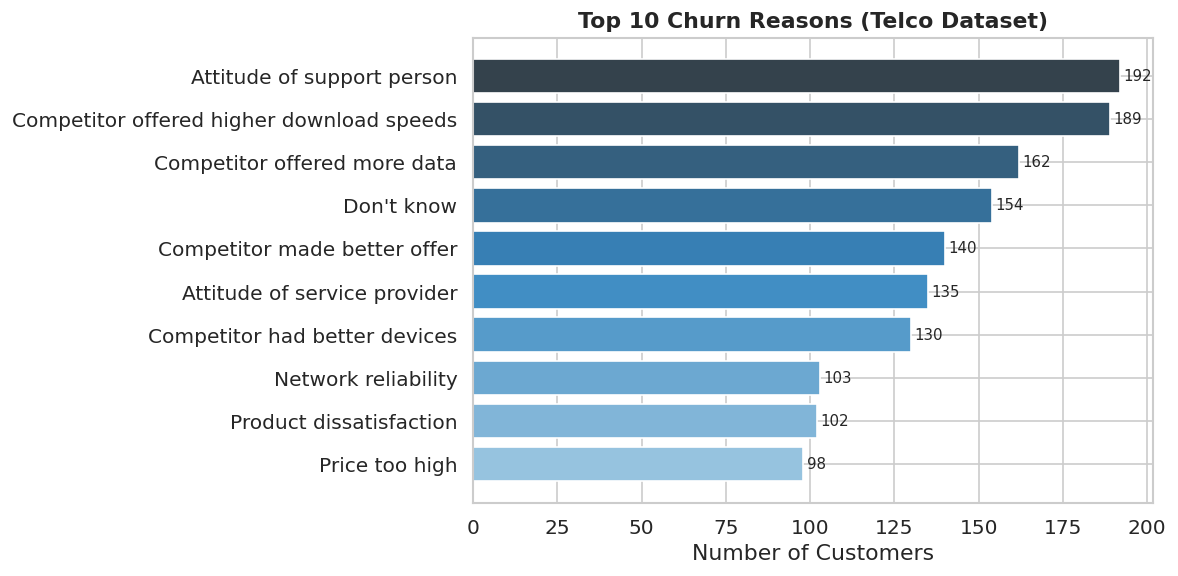

In [17]:
# Churn reason (churners only)
churn_reasons = (telco[telco['Churn Label'] == 'Yes']['Churn Reason']
                 .value_counts()
                 .head(10))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(churn_reasons.index[::-1], churn_reasons.values[::-1],
               color=sns.color_palette('Blues_d', len(churn_reasons)))
ax.set_title('Top 10 Churn Reasons (Telco Dataset)', fontweight='bold')
ax.set_xlabel('Number of Customers')
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES}/06_churn_reasons.png', bbox_inches='tight')
plt.show()

## 7. Telco Dataset — Correlation Analysis

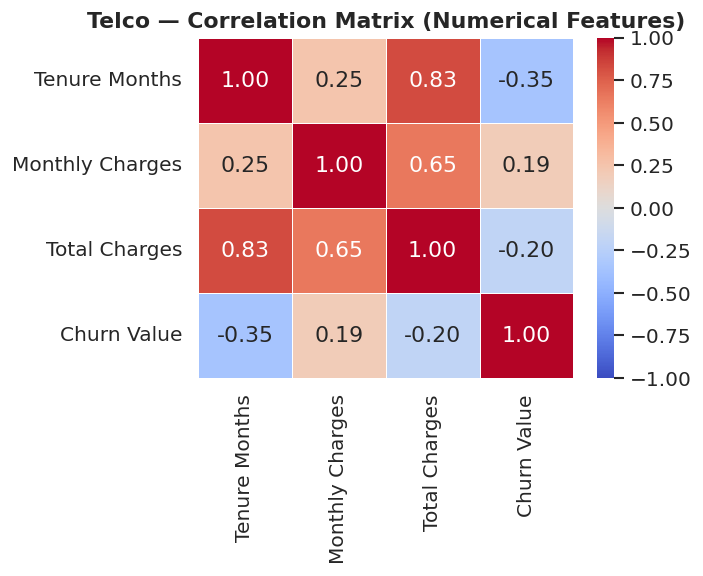

In [18]:
telco_corr = telco[['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(telco_corr, dtype=bool), k=1)
sns.heatmap(telco_corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Telco — Correlation Matrix (Numerical Features)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES}/07_telco_correlation.png', bbox_inches='tight')
plt.show()

## 8. India Dataset — EDA

In [20]:
# Descriptive stats for numerical features
india_num_cols = ['age', 'annual_income_lakhs', 'monthly_charges', 'tenure_months',
                  'total_charges', 'data_usage_gb', 'voice_minutes', 'sms_count',
                  'payment_delays_last_6m', 'support_calls_last_month',
                  'network_satisfaction', 'price_satisfaction', 'overall_satisfaction',
                  'competitor_offers_received', 'price_sensitivity_score']
print('=== India Dataset — Descriptive Statistics ===')
display(india[india_num_cols].describe().round(2))

=== India Dataset — Descriptive Statistics ===


,age,annual_income_lakhs,monthly_charges,tenure_months,total_charges,data_usage_gb,voice_minutes,sms_count,payment_delays_last_6m,support_calls_last_month,network_satisfaction,price_satisfaction,overall_satisfaction,competitor_offers_received,price_sensitivity_score
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.0,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,32.44,16.47,544.84,17.60,9548.05,29.47,302.62,55.29,0.5,0.79,5.47,5.49,5.50,2.50,5.53
std,10.69,12.57,493.84,17.74,15421.13,21.01,246.08,26.47,0.7,0.89,2.87,2.87,2.87,1.71,2.87
min,18.00,2.00,99.00,1.00,100.00,1.00,50.00,10.00,0.0,0.00,1.00,1.00,1.00,0.00,1.00
25%,24.00,7.00,239.00,5.00,1675.50,14.00,121.00,33.00,0.0,0.00,3.00,3.00,3.00,1.00,3.00
50%,32.00,12.99,420.00,12.00,4560.00,25.00,235.00,55.00,0.0,1.00,5.00,6.00,5.00,3.00,6.00
75%,40.00,22.38,664.00,25.00,11130.50,40.00,410.00,78.00,1.0,1.00,8.00,8.00,8.00,4.00,8.00
max,77.00,67.49,2999.00,160.00,279110.00,192.00,2403.00,100.00,5.0,7.00,10.00,10.00,10.00,5.00,10.00


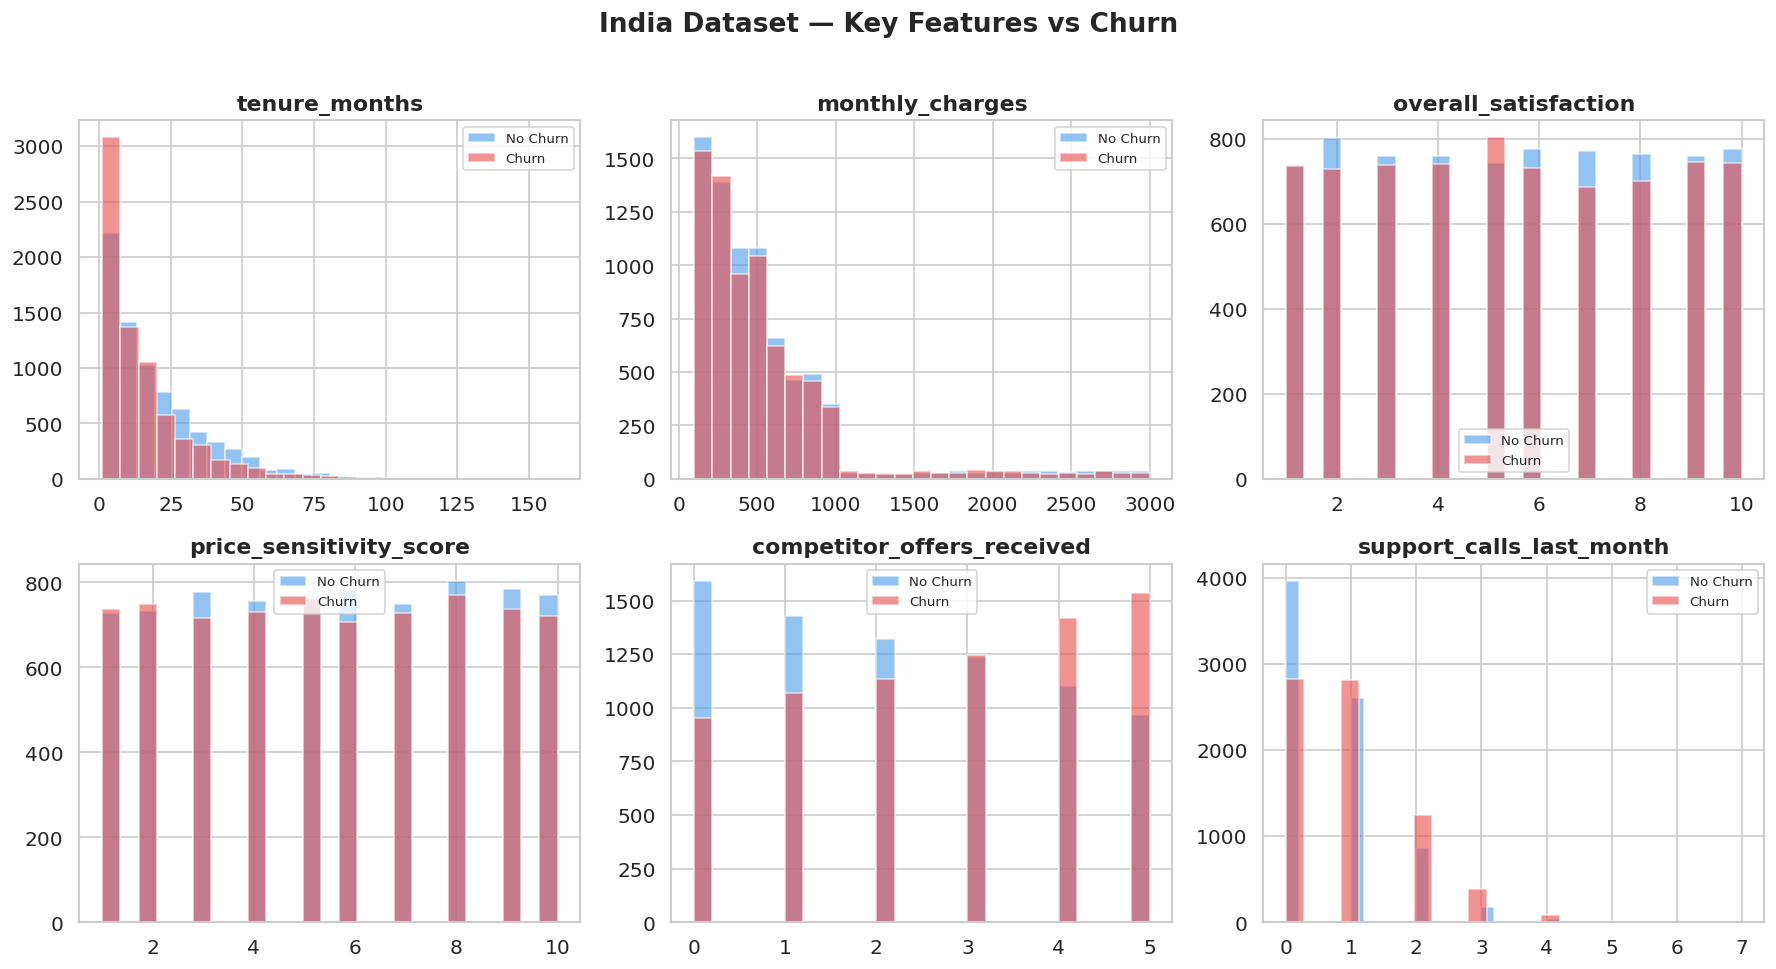

In [21]:
# Key numerical features vs churn
india['churn_bin'] = (india['churn'] == 'Yes').astype(int)
key_num = ['tenure_months', 'monthly_charges', 'overall_satisfaction',
           'price_sensitivity_score', 'competitor_offers_received', 'support_calls_last_month']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
palette = {0: '#4c9be8', 1: '#e84c4c'}

for ax, col in zip(axes, key_num):
    for label, grp in india.groupby('churn_bin'):
        ax.hist(grp[col].dropna(), bins=25, alpha=0.6,
                label='No Churn' if label == 0 else 'Churn',
                color=palette[label], edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('India Dataset — Key Features vs Churn', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/08_india_features_vs_churn.png', bbox_inches='tight')
plt.show()

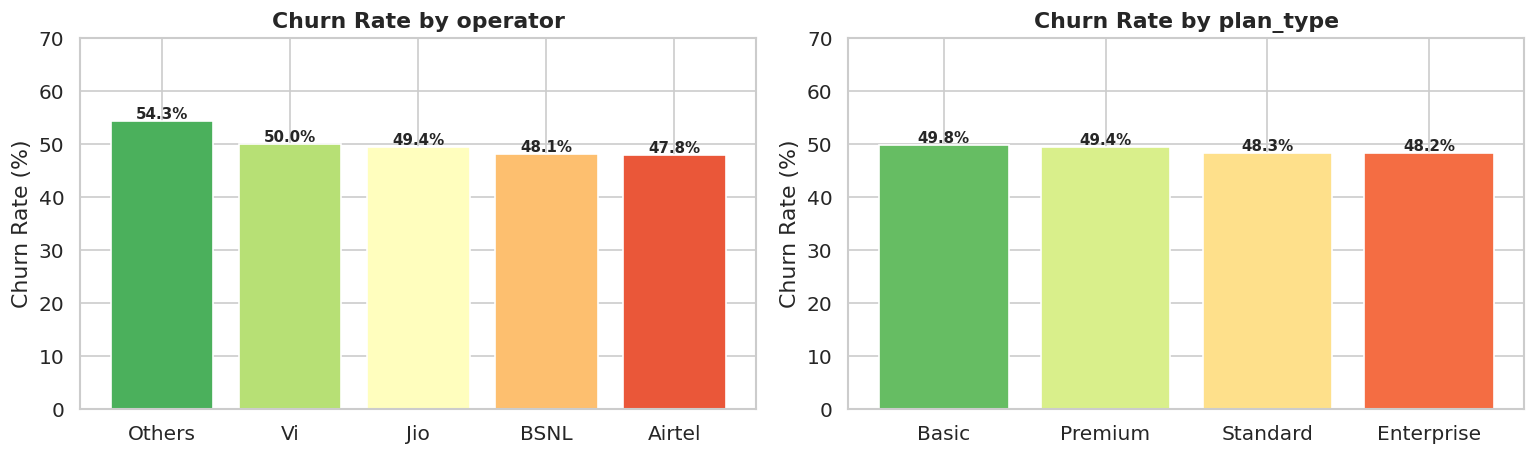

In [22]:
# Operator & plan_type churn rates
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col in zip(axes, ['operator', 'plan_type']):
    cr = (india.groupby(col)['churn_bin'].mean() * 100).sort_values(ascending=False).round(1)
    bars = ax.bar(cr.index, cr.values, color=sns.color_palette('RdYlGn_r', len(cr)))
    ax.set_title(f'Churn Rate by {col}', fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 70)
    for bar, v in zip(bars, cr.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES}/09_india_cat_vs_churn.png', bbox_inches='tight')
plt.show()

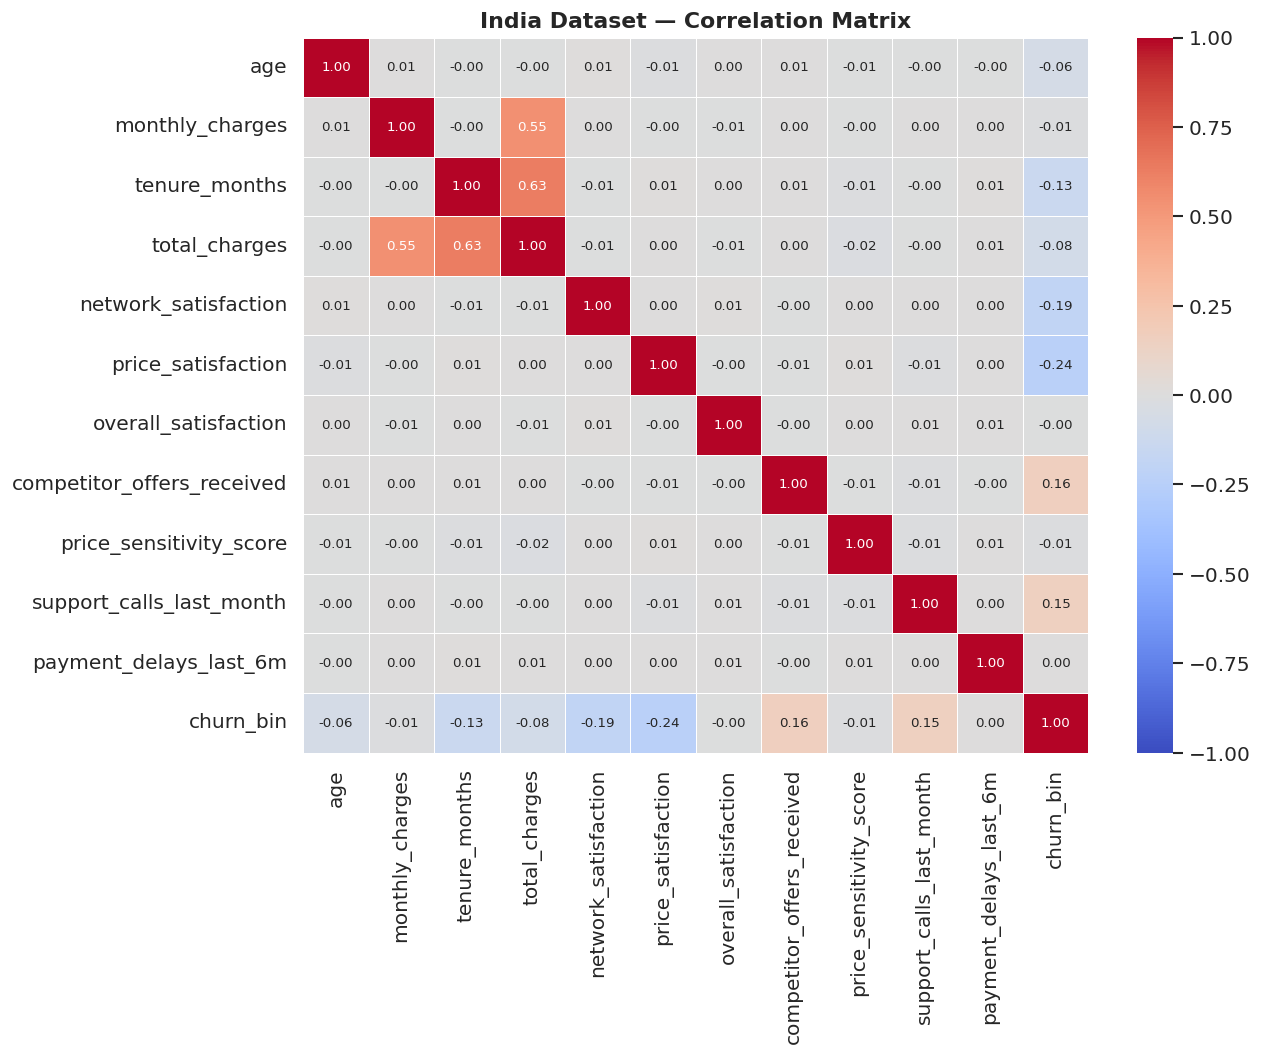

In [23]:
# India correlation heatmap
india_corr_cols = ['age', 'monthly_charges', 'tenure_months', 'total_charges',
                   'network_satisfaction', 'price_satisfaction', 'overall_satisfaction',
                   'competitor_offers_received', 'price_sensitivity_score',
                   'support_calls_last_month', 'payment_delays_last_6m', 'churn_bin']
corr_matrix = india[india_corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.4, vmin=-1, vmax=1, annot_kws={'size': 8})
ax.set_title('India Dataset — Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES}/10_india_correlation.png', bbox_inches='tight')
plt.show()

## 9. Key EDA Observations

### Telco Dataset (IBM-inspired, US)
| Observation | Detail |
|---|---|
| **Class imbalance** | 73.5% No Churn vs 26.5% Churn — SMOTE required |
| **Contract type is decisive** | Month-to-month customers churn at ~42% vs <10% for 1- or 2-year contracts |
| **Fiber optic customers churn more** | ~42% churn rate vs ~19% for DSL |
| **Short-tenure customers at high risk** | Churners cluster in first 12 months |
| **Monthly Charges** | Churners pay higher monthly charges on average |
| **Electronic check payment** | Highest churn rate among payment methods |
| **Top churn reason** | Competitor attitude / better offers |
| **Total Charges dtype** | Object — contains whitespace entries; will be coerced to float |

### India Dataset
| Observation | Detail |
|---|---|
| **Near-balanced classes** | 51% No / 49% Yes — SMOTE less critical but still applied |
| **Overall satisfaction** | Strong negative correlation with churn |
| **Competitor offers received** | Positive correlation with churn |
| **Price sensitivity score** | Higher scores → higher churn |
| **`churn_probability` column** | Must be excluded (target leakage) |
| **PII columns** | `customer_id`, `name`, `phone`, `pincode` — drop before modeling |

### Preprocessing Actions Required
1. Telco: Coerce `Total Charges` to float; drop `CustomerID`, `Count`, `Country`, `Lat Long`, `Latitude`, `Longitude`, `Churn Score`, `CLTV`, `Churn Reason`, `Churn Label` (keep `Churn Value` as target)
2. India: Drop PII (`customer_id`, `name`, `phone`), drop `churn_probability` (leakage), drop `city`/`state`/`pincode` (high-cardinality geography)
3. Both: One-Hot Encode categoricals, Z-score scale numerics, apply SMOTE to training set

In [24]:
print('Milestone 1 — EDA COMPLETE')
print(f'Figures saved to: {FIGURES}')
import os
for f in sorted(os.listdir(FIGURES)):
    print(' ', f)

Milestone 1 — EDA COMPLETE
Figures saved to: ../reports/figures
  01_churn_distribution.png
  02_telco_num_distributions.png
  03_telco_cat_distributions.png
  04_telco_num_vs_churn.png
  05_telco_cat_vs_churn.png
  06_churn_reasons.png
  07_telco_correlation.png
  08_india_features_vs_churn.png
  09_india_cat_vs_churn.png
  10_india_correlation.png
  11_smote_telco.png
